# Separate gap-filling for 2+ weeks in 2012

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

- Tricky gap in 2012
- Random forest models were not able to predict fluxes satisfactorily between 27 Feb 2012 8:00 and 16 Mar 2012 18:00
- Here MDS is used to fill this short time period
- First, the time period is removed from the *gap-filled* fluxes that were previously gap-filled with random forest
- Next, MDS is used to gap-fill the time period, using SW_IN, TS and SWC as predictors
- This produced a more realistic flux pattern during this period

</br>

# Settings

In [1]:
FLUX = "FCH4"
USTAR = "84"
gain = 0.000216198  # Conversion factor to convert nmol CH4 m-2 s-1 to kg CH4-C ha-1
units = r'($\mathrm{kg\ CH_4-C\ ha^{-1}}$)'  # Units for CH4 flux, used in cumulative plots only

# Imports

In [2]:
import importlib.metadata
import datetime as dt
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.timeseries import TimeSeries  # For simple (interactive) time series plotting
from diive.core.dfun.stats import sstats  # Time series stats
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.pkgs.gapfilling.mds import FluxMDS
from diive.core.plotting.cumulative import CumulativeYear
import warnings
warnings.filterwarnings('ignore')
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.87.0


# Define variables

In [3]:
# Target variable
target = f"{FLUX}_L3.1_L3.3_CUT_{USTAR}_QCF_gfRF"
flag = f"FLAG_{target}_ISFILLED"
print(target, flag)

FCH4_L3.1_L3.3_CUT_84_QCF_gfRF FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED


In [4]:
# Predictors, only meteo vars for MDS
METEO_VARS = ["TS_GF1_0.04_1_gfXG", "SWC_GF1_0.15_1_gfXG", "SW_IN_T1_2_1"]
print(METEO_VARS)

['TS_GF1_0.04_1_gfXG', 'SWC_GF1_0.15_1_gfXG', 'SW_IN_T1_2_1']


# Load main data (contains predictors)

In [5]:
SOURCEDIR = r"../30_MERGE_DATA"
FILENAME = r"33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
print(f"Data will be loaded from the following file:\n{FILEPATH}")
MAIN_df = load_parquet(filepath=FILEPATH)
_locs = (MAIN_df.index.year >= 2012) & (MAIN_df.index.year <= 2012)
MAIN_df = MAIN_df[_locs].copy()
PREDICTORS_df = MAIN_df[METEO_VARS].copy()
PREDICTORS_df

Data will be loaded from the following file:
..\30_MERGE_DATA\33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet
Loaded .parquet file ..\30_MERGE_DATA\33.5_CH-CHA_IRGA+QCL+LGR+M10+MGMT_Level-1_eddypro_fluxnet_2005-2024.parquet (0.447 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,TS_GF1_0.04_1_gfXG,SWC_GF1_0.15_1_gfXG,SW_IN_T1_2_1
TIMESTAMP_MIDDLE,,,
2012-01-01 00:15:00,4.4616,47.828381,0.0
2012-01-01 00:45:00,4.4662,47.830925,0.0
2012-01-01 01:15:00,4.4702,47.838543,0.0
2012-01-01 01:45:00,4.5145,47.841091,0.0
2012-01-01 02:15:00,4.5171,47.848713,0.0
...,...,...,...
2012-12-31 21:45:00,3.7552,47.014778,0.0
2012-12-31 22:15:00,3.7072,47.015614,0.0
2012-12-31 22:45:00,3.6226,47.022266,0.0


# Load (previously corrected) gap-filled fluxes 2012
- Contains gap-filled flux and flag

In [6]:
SOURCEDIR = r""
FILENAME = r"52.8d_CorrectionGapFilling_L4.1_FCH4_CUT_165084.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
FLUX_df = load_parquet(filepath=FILEPATH)
FLUX_ALL_df = FLUX_df.copy()  # All years
_locs = (FLUX_df.index.year >= 2012) & (FLUX_df.index.year <= 2012)
FLUX_df = FLUX_df[_locs].copy()
FLUX_df

Loaded .parquet file 52.8d_CorrectionGapFilling_L4.1_FCH4_CUT_165084.parquet (0.041 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,FCH4,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_FCH4_MISSING_TEST,FLAG_L2_FCH4_SSITC_TEST,FLAG_L2_FCH4_COMPLETENESS_TEST,FLAG_L2_FCH4_SCF_TEST,FLAG_L2_FCH4_CH4_VM97_SPIKE_HF_TEST,FLAG_L2_FCH4_CH4_VM97_AMPLITUDE_RESOLUTION_HF_TEST,FLAG_L2_FCH4_CH4_VM97_DROPOUT_TEST,FLAG_L2_FCH4_VM97_AOA_HF_TEST,SUM_L2_FCH4_HARDFLAGS,SUM_L2_FCH4_SOFTFLAGS,...,FCH4_L3.1_L3.3_CUT_50_QCF,FCH4_L3.1_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.1_USTAR_TEST,SUM_L3.3_CUT_84_FCH4_L3.1_HARDFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_SOFTFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_FLAGS,FLAG_L3.3_CUT_84_FCH4_L3.1_QCF,FCH4_L3.1_L3.3_CUT_84_QCF,FCH4_L3.1_L3.3_CUT_84_QCF0,FCH4_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:15:00,NaN,0.191226,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,80.517853,1.0,45.313383,1.0,59.083978,1.0
2012-01-01 00:45:00,NaN,0.056639,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.957530,1.0,27.507597,1.0,45.504401,1.0
2012-01-01 01:15:00,NaN,0.105926,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,72.691594,1.0,26.429539,1.0,46.598200,1.0
2012-01-01 01:45:00,NaN,0.061007,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.723650,1.0,41.049285,1.0,52.982494,1.0
2012-01-01 02:15:00,NaN,0.079177,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.424592,1.0,39.003937,1.0,48.701840,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 21:45:00,-31.96100,0.064993,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,0.999417,1.0,-12.325713,1.0,9.917033,1.0
2012-12-31 22:15:00,5.61567,0.059460,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,1.217887,1.0,-14.303247,1.0,10.464530,1.0
2012-12-31 22:45:00,-31.89790,0.058793,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,1.0,...,NaN,NaN,2.0,2.0,1.0,3.0,2.0,NaN,NaN,-28.888520,0.0,-11.520008,1.0,15.686061,1.0


# Cumulative: before

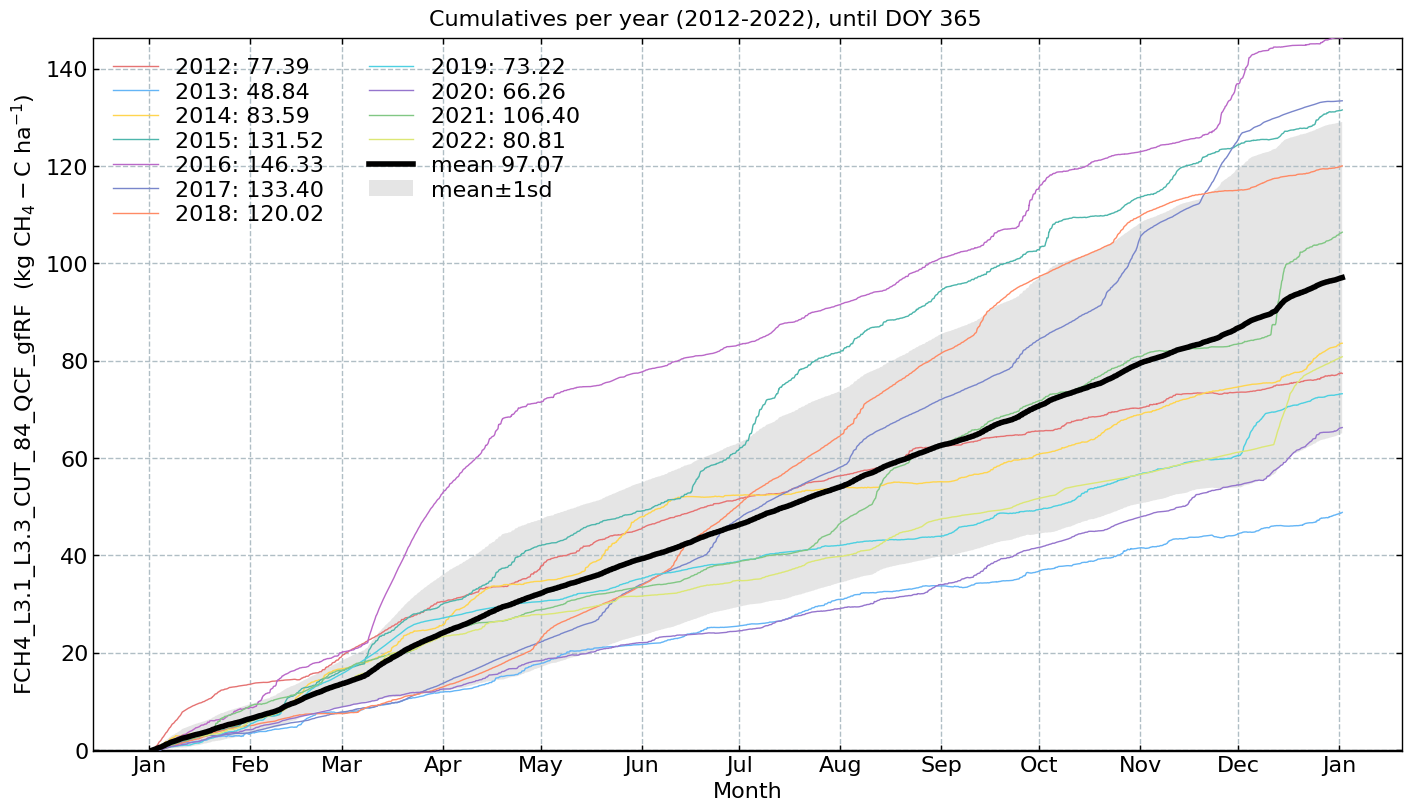

In [7]:
s = FLUX_ALL_df[target].copy()
s = s.multiply(gain)

CumulativeYear(
    series=s,
    series_units=units,
    yearly_end_date=None,
    # yearly_end_date='08-11',
    start_year=2012,
    end_year=2022,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=None,
    highlight_year_color='#F44336').plot()

# Merge measured flux (gap-filled) with predictors

In [8]:
subset = pd.concat([FLUX_df[target], PREDICTORS_df], axis=1)
subset

,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,TS_GF1_0.04_1_gfXG,SWC_GF1_0.15_1_gfXG,SW_IN_T1_2_1
TIMESTAMP_MIDDLE,,,,
2012-01-01 00:15:00,59.083978,4.4616,47.828381,0.0
2012-01-01 00:45:00,45.504401,4.4662,47.830925,0.0
2012-01-01 01:15:00,46.598200,4.4702,47.838543,0.0
2012-01-01 01:45:00,52.982494,4.5145,47.841091,0.0
2012-01-01 02:15:00,48.701840,4.5171,47.848713,0.0
...,...,...,...,...
2012-12-31 21:45:00,9.917033,3.7552,47.014778,0.0
2012-12-31 22:15:00,10.464530,3.7072,47.015614,0.0
2012-12-31 22:45:00,15.686061,3.6226,47.022266,0.0


# Identify exact start and end of problematic time period
I checked the eddy covariance raw data plots (20Hz):
- `2012022702.b00` is the last complete raw data file before the gap, N2O and CH4 look good
- `2012022708.b00` is the last complete raw data file before the gap, but N2O and CH4 measurements by the QCL are already faulty
- `2012022714.b00` is the first incomplete raw data file already *during* the gap (N2O and CH4 completely missing)
- `2012031602.b00` is the last incomplete raw data file already *during* the gap (N2O and CH4 completely missing)
- `2012031614.b00` is the first complete raw data file after the gap, N2O and CH4 look good again after approx. 18:00h
- `2012031620.b00` is the first complete raw data file after the gap, N2O and CH4 look good again

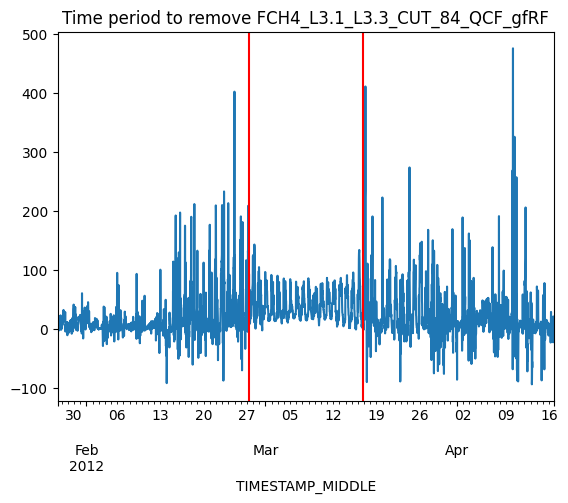

In [9]:
# Removal dates
remove_from = datetime(2012, 2, 27, 8, 0)
remove_until = datetime(2012, 3, 16, 18, 0)

# For SUBSET
replacelocs = (subset.index >= remove_from) & (subset.index <= remove_until)
show_locs = (subset.index >= datetime(2012, 1, 27, 8, 0)) & (subset.index <= datetime(2012, 4, 16, 18, 0))  # For plotting

# For full dataframe with all years
replacelocs_all = (FLUX_ALL_df.index >= remove_from) & (FLUX_ALL_df.index <= remove_until)

ax = subset[target].loc[show_locs].plot(title=f"Time period to remove {target}")
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

# Remove fluxes on dates

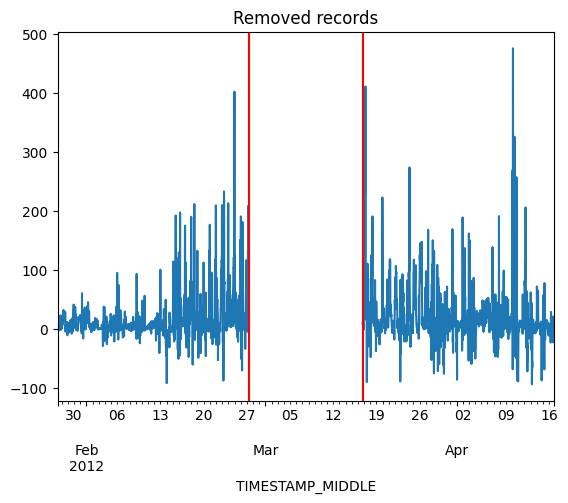

In [10]:
subset[target].loc[replacelocs] = np.nan
ax = subset[target].loc[show_locs].plot(title="Removed records")
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

# Gap-filling

## Init

In [11]:
settings = dict()
mds = FluxMDS(
    df=subset,
    flux=target,
    ta='TS_GF1_0.04_1_gfXG',
    swin='SW_IN_T1_2_1',
    vpd='SWC_GF1_0.15_1_gfXG',
    swin_tol=[20, 50],
    ta_tol=2.5,
    vpd_tol=2.5,
    avg_min_n_vals=5
)

## Run

In [12]:
mds.run()


Starting MDS gap-filling of flux FCH4_L3.1_L3.3_CUT_84_QCF_gfRF.
MDS gap-filling quality 1    using SW_IN, TA, VPD in 7 days window ...
MDS gap-filling quality 2    using SW_IN, TA, VPD in 14 days window ...
MDS gap-filling quality 3    using SW_IN in 7 days window ...
MDS gap-filling quality 4    using mean diurnal cycle of flux in 0 days, 1 hours window ...
MDS gap-filling quality 5    using mean diurnal cycle of flux in 1 days, 1 hours window ...
MDS gap-filling quality 6    using SW_IN, TA, VPD in 21 days window ...
MDS gap-filling quality 7    using SW_IN, TA, VPD in 28 days window ...
MDS gap-filling quality 8    using SW_IN in 14 days window ...
MDS gap-filling quality 9    using SW_IN, TA, VPD in 35 days window ...
MDS gap-filling quality 10    using SW_IN, TA, VPD in 42 days window ...
MDS gap-filling quality 11    using SW_IN, TA, VPD in 49 days window ...
MDS gap-filling quality 12    using SW_IN, TA, VPD in 56 days window ...
MDS gap-filling quality 13    using SW_IN, TA, 

## Report


FCH4_L3.1_L3.3_CUT_84_QCF_gfRF before gap-filling:
    17568 potential values
    16684 available values
    884 missing values

FCH4_L3.1_L3.3_CUT_84_QCF_gfRF after gap-filling (FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_gfMDS):
    17568 potential values
    17568 available values
    0 missing values
    1.061 predictions mean quality across all records (1=best)

Gap-filling quality flags (FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_gfMDS_ISFILLED):
    Directly measured: 16684 values (flag=0)
    Gap-filling quality 1.0: 432 values (flag=1.0)
    Gap-filling quality 2.0: 337 values (flag=2.0)
    Gap-filling quality 3.0: 29 values (flag=3.0)
    Gap-filling quality 6.0: 62 values (flag=6.0)
    Gap-filling quality 7.0: 5 values (flag=7.0)
    Gap-filling quality 8.0: 15 values (flag=8.0)
    Gap-filling quality 25.0: 2 values (flag=25.0)
    Gap-filling quality 26.0: 2 values (flag=26.0)

MDS gap-filling scores:
    mae: 22.810
    medae: 13.598
    mse: 1486.002
    rmse: 38.549
    mape: 5.158
    

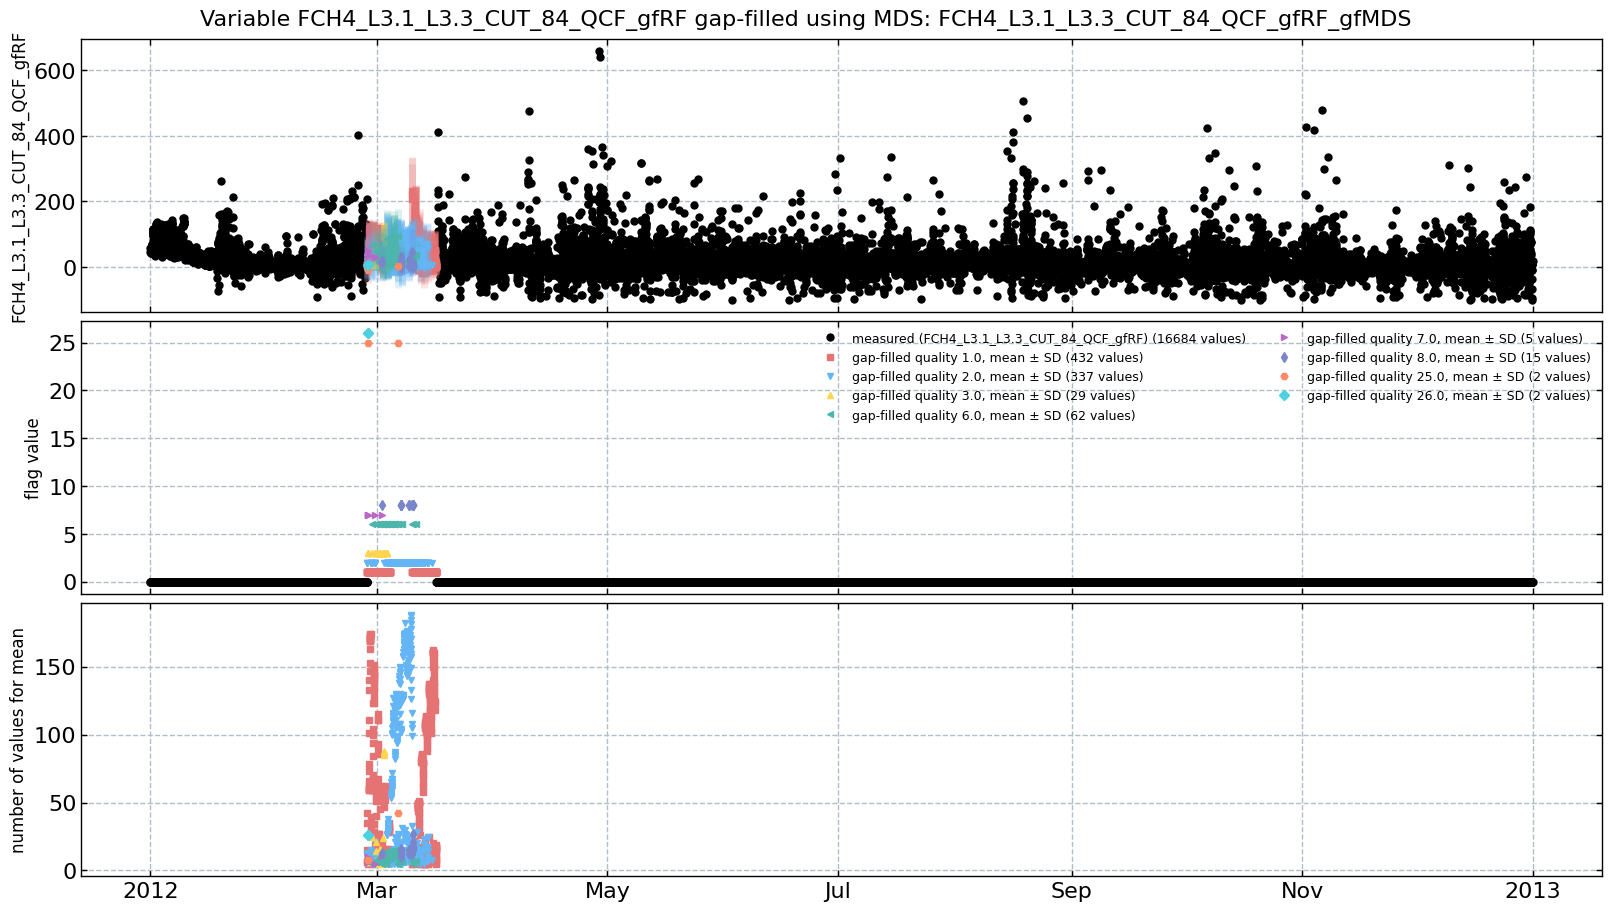

In [13]:
mds.report()
mds.showplot()

# Results

In [14]:
var_new_gapfilled = mds.get_gapfilled_target().name
var_new_flag = mds.get_flag().name
new_gapfilling_df = mds.gapfilling_df_

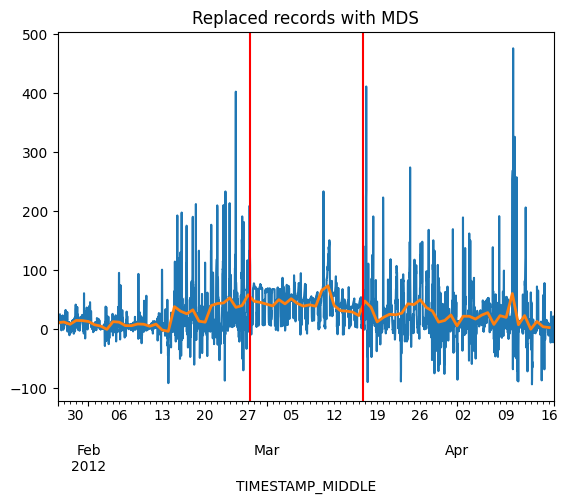

In [15]:
ax = new_gapfilling_df[var_new_gapfilled].loc[show_locs].plot(title="Replaced records with MDS")
ax = new_gapfilling_df[var_new_gapfilled].loc[show_locs].resample('D').mean().plot(title="Replaced records with MDS", lw=2)
plt.axvline(remove_from, color="red")
plt.axvline(remove_until, color="red");

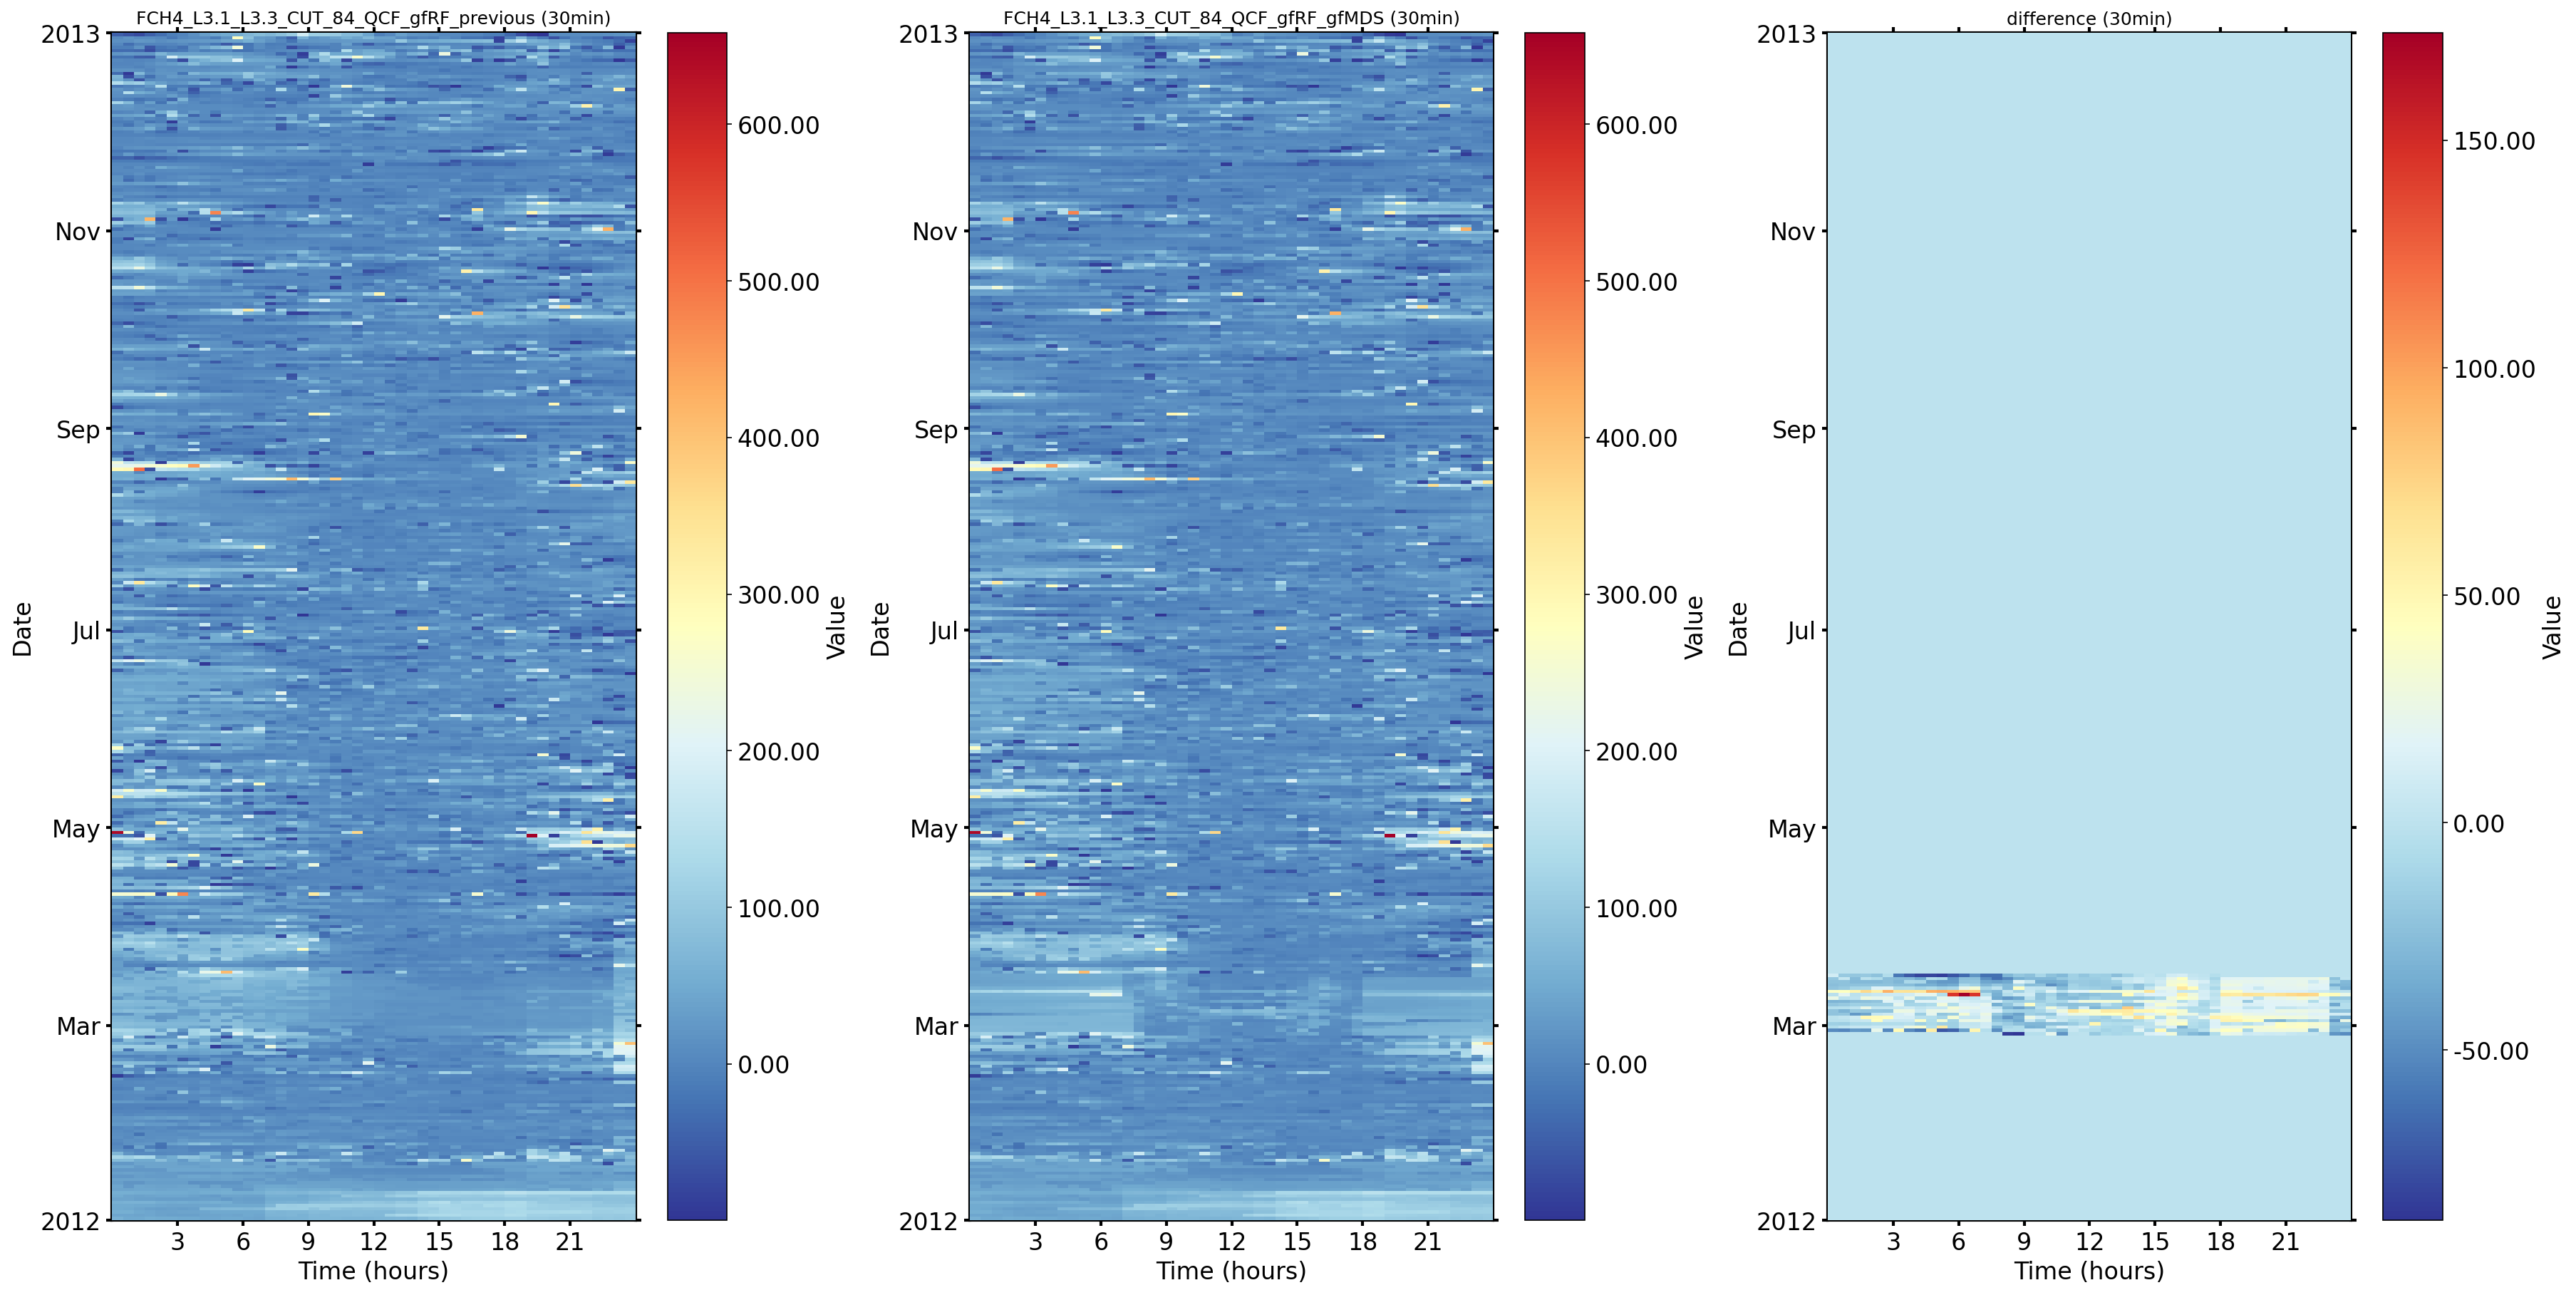

In [16]:
# Store previously gap-filled flux For comparison
flux_gapfilled_orig = FLUX_df[target].copy()  
flux_gapfilled_orig.name = f"{target}_previous"
diff = new_gapfilling_df[var_new_gapfilled].sub(flux_gapfilled_orig)
diff.name = "difference"
fig, axs = plt.subplots(ncols=3, figsize=(24, 12), dpi=150, layout="constrained")
HeatmapDateTime(series=flux_gapfilled_orig, ax=axs[0]).plot()  # Gap-filled flux from previous gap-filling
HeatmapDateTime(series=new_gapfilling_df[var_new_gapfilled], ax=axs[1]).plot()  # New gap-filling
HeatmapDateTime(series=diff, ax=axs[2]).plot()  # Difference between previous gap-filling and new gap-filling, to check if it worked for the three years

# Add 2+ weeks back to main data

In [17]:
FLUX_ALL_df.loc[replacelocs_all, target]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00    92.970371
2012-02-27 08:45:00    91.762128
2012-02-27 09:15:00     9.486654
2012-02-27 09:45:00    10.514053
2012-02-27 10:15:00     8.769251
                         ...    
2012-03-16 15:45:00     4.731570
2012-03-16 16:15:00     1.644743
2012-03-16 16:45:00     2.395061
2012-03-16 17:15:00     3.785128
2012-03-16 17:45:00     6.510802
Freq: 30min, Name: FCH4_L3.1_L3.3_CUT_84_QCF_gfRF, Length: 884, dtype: float64

## Remove records from previous gap-filling

In [18]:
FLUX_ALL_df.loc[replacelocs_all, target] = np.nan
FLUX_ALL_df.loc[replacelocs_all, flag] = np.nan
FLUX_ALL_df.loc[replacelocs_all, target]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00   NaN
2012-02-27 08:45:00   NaN
2012-02-27 09:15:00   NaN
2012-02-27 09:45:00   NaN
2012-02-27 10:15:00   NaN
                       ..
2012-03-16 15:45:00   NaN
2012-03-16 16:15:00   NaN
2012-03-16 16:45:00   NaN
2012-03-16 17:15:00   NaN
2012-03-16 17:45:00   NaN
Freq: 30min, Name: FCH4_L3.1_L3.3_CUT_84_QCF_gfRF, Length: 884, dtype: float64

## Fill new gap-filling into gaps

In [19]:
FLUX_ALL_df.loc[replacelocs_all, target] = new_gapfilling_df.loc[replacelocs, var_new_gapfilled]
FLUX_ALL_df.loc[replacelocs_all, flag] = new_gapfilling_df.loc[replacelocs, var_new_flag]
FLUX_ALL_df.loc[replacelocs_all, target]

TIMESTAMP_MIDDLE
2012-02-27 08:15:00     8.111891
2012-02-27 08:45:00     4.323654
2012-02-27 09:15:00     5.687144
2012-02-27 09:45:00     6.888534
2012-02-27 10:15:00    30.911151
                         ...    
2012-03-16 15:45:00    14.404025
2012-03-16 16:15:00    13.414920
2012-03-16 16:45:00     5.317647
2012-03-16 17:15:00     4.462061
2012-03-16 17:45:00     1.733177
Freq: 30min, Name: FCH4_L3.1_L3.3_CUT_84_QCF_gfRF, Length: 884, dtype: float64

## Plot heatmaps

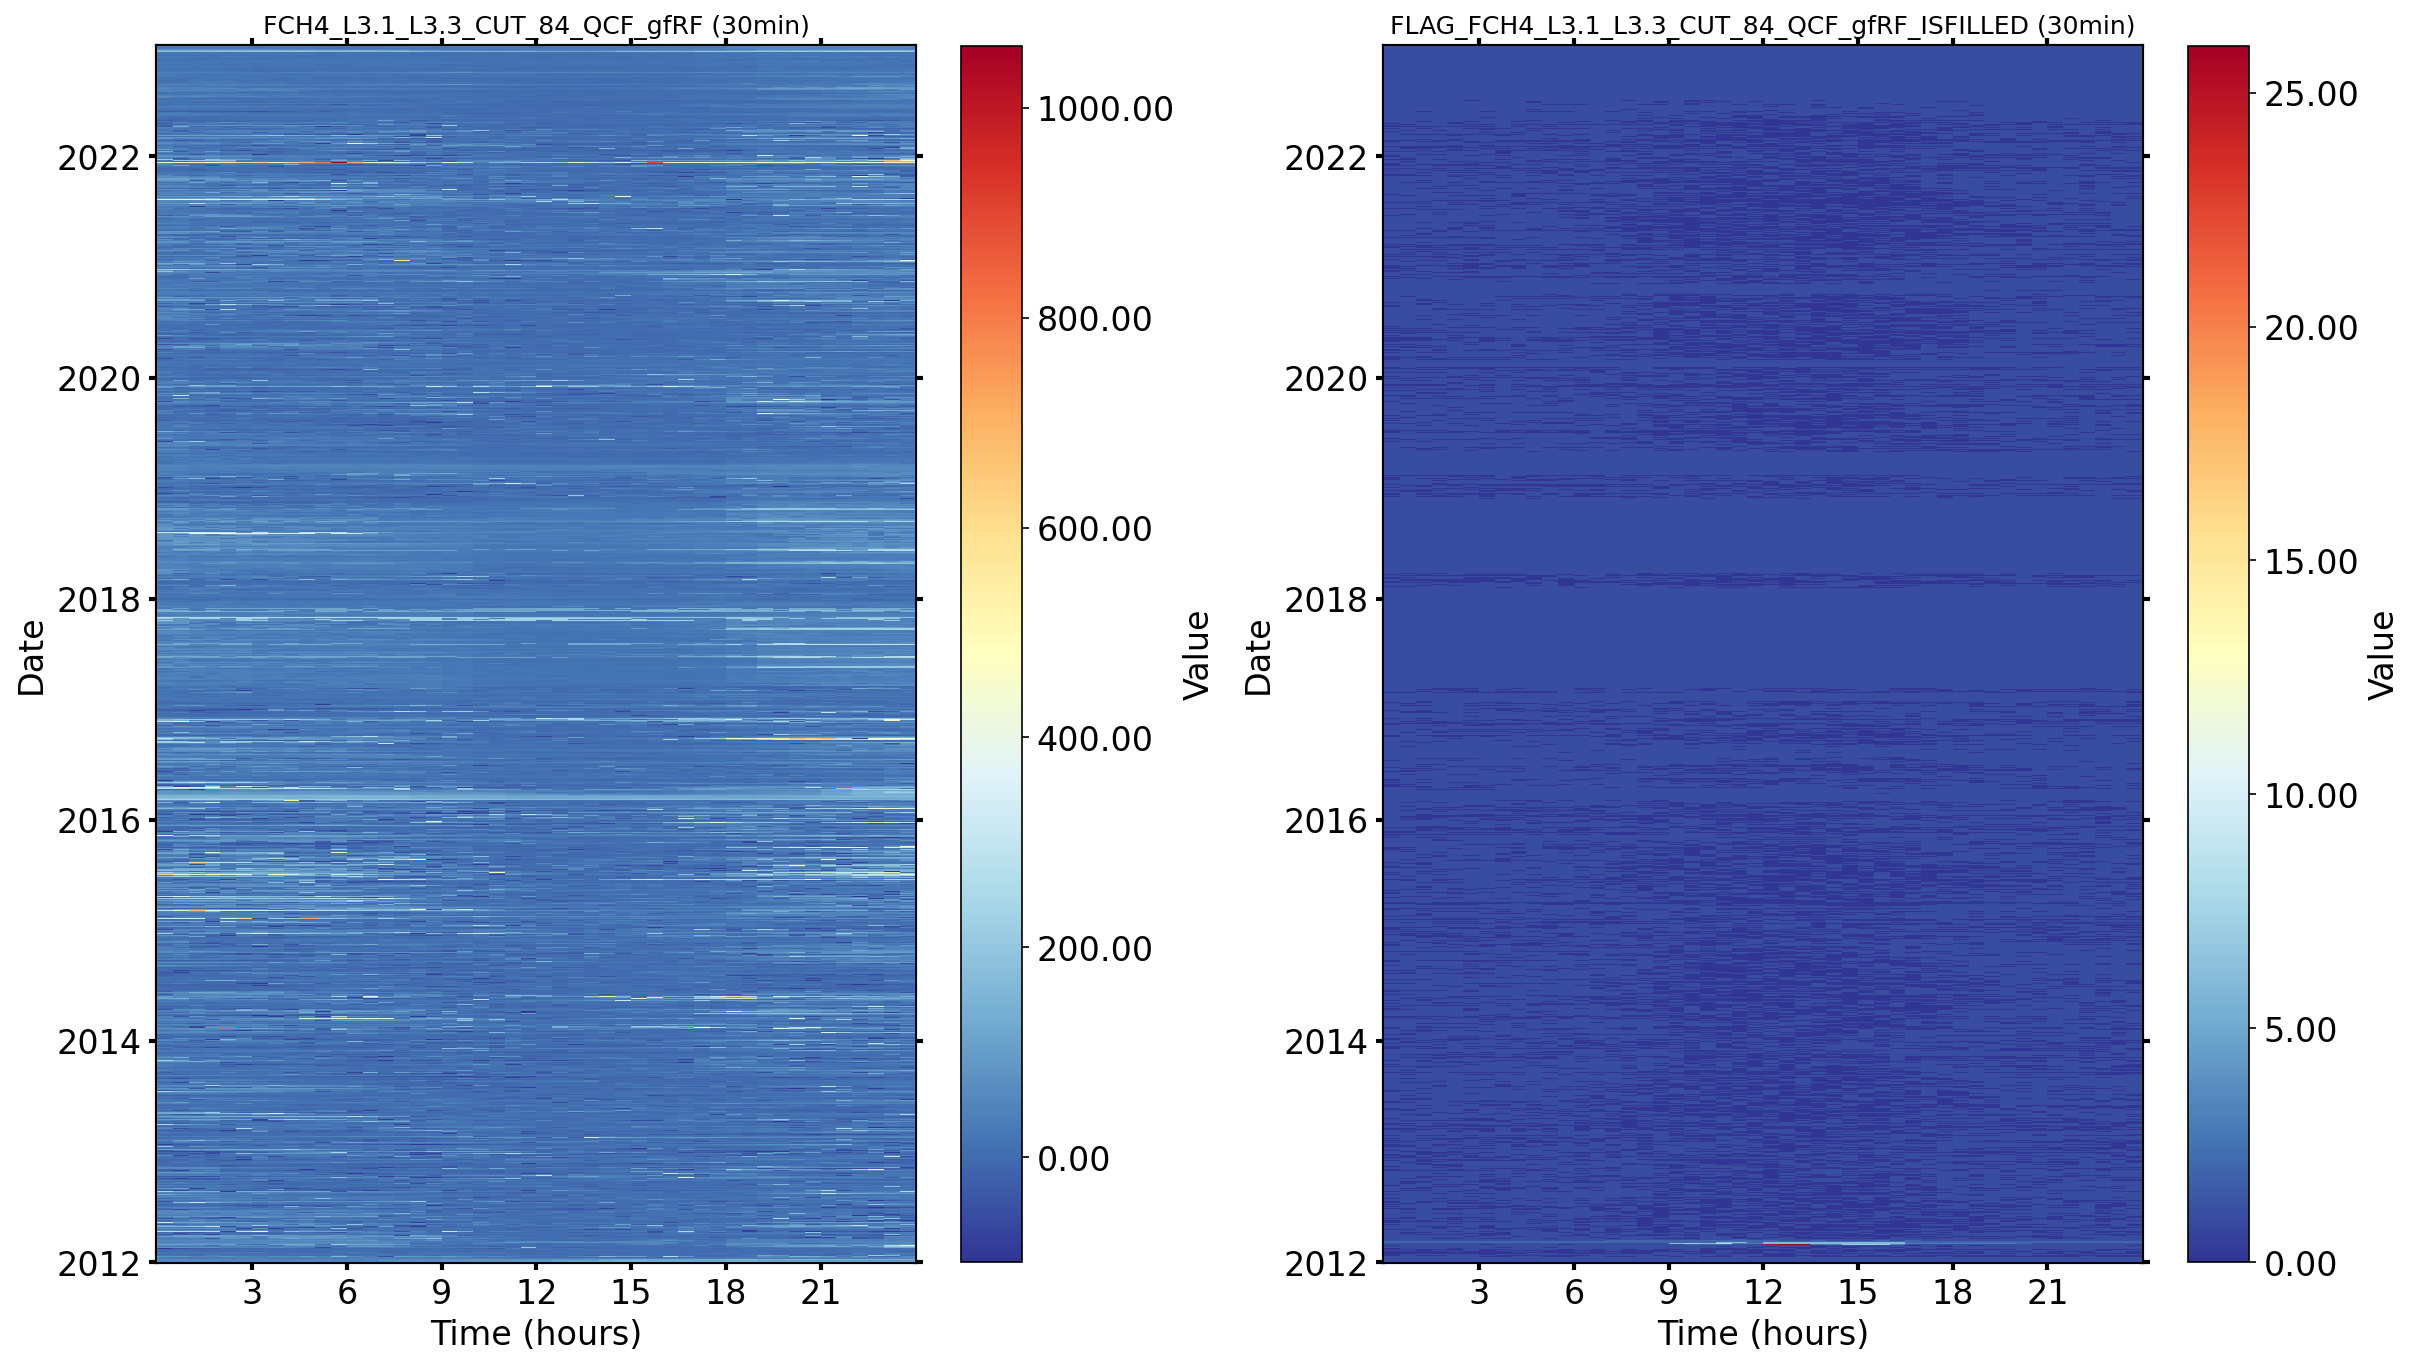

In [20]:
fig, axs = plt.subplots(ncols=2, figsize=(16, 9), dpi=150, layout="constrained")
HeatmapDateTime(series=FLUX_ALL_df[target], ax=axs[0]).plot()  # New gap-filling in the three years
HeatmapDateTime(series=FLUX_ALL_df[flag], ax=axs[1]).plot()  #  Different scaling! Shows where OLD was replaced with NEW

# Cumulatives: after

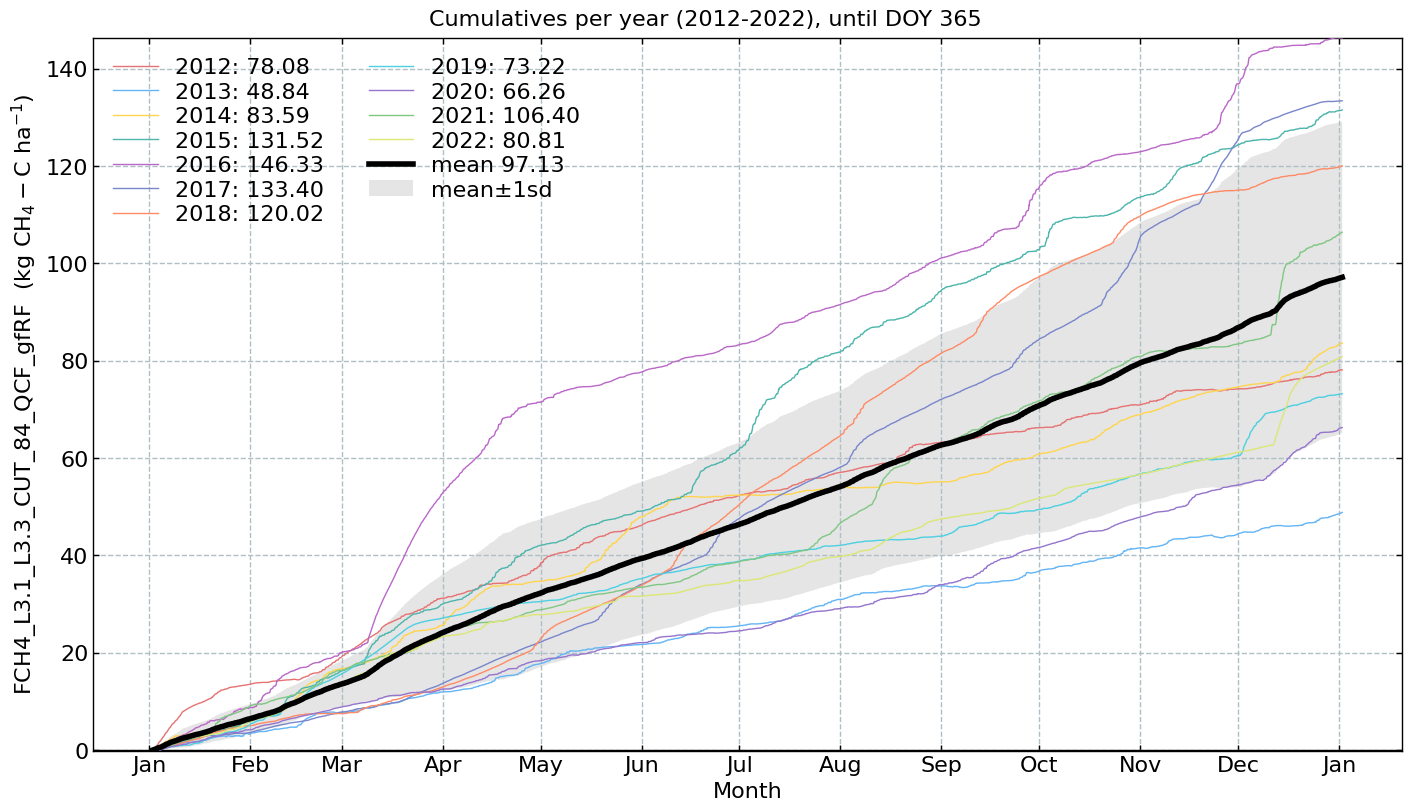

In [21]:
s = FLUX_ALL_df[target].copy()
s = s.multiply(gain)

CumulativeYear(
    series=s,
    series_units=units,
    yearly_end_date=None,
    # yearly_end_date='08-11',
    start_year=2012,
    end_year=2022,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=None,
    highlight_year_color='#F44336').plot()

# **Save to file**

In [22]:
FLUX_ALL_df

,FCH4,USTAR,SW_IN_POT,DAYTIME,NIGHTTIME,FLAG_L2_FCH4_MISSING_TEST,FLAG_L2_FCH4_SSITC_TEST,FLAG_L2_FCH4_COMPLETENESS_TEST,FLAG_L2_FCH4_SCF_TEST,FLAG_L2_FCH4_CH4_VM97_SPIKE_HF_TEST,FLAG_L2_FCH4_CH4_VM97_AMPLITUDE_RESOLUTION_HF_TEST,FLAG_L2_FCH4_CH4_VM97_DROPOUT_TEST,FLAG_L2_FCH4_VM97_AOA_HF_TEST,SUM_L2_FCH4_HARDFLAGS,SUM_L2_FCH4_SOFTFLAGS,...,FCH4_L3.1_L3.3_CUT_50_QCF,FCH4_L3.1_L3.3_CUT_50_QCF0,FLAG_L3.3_CUT_84_FCH4_L3.1_USTAR_TEST,SUM_L3.3_CUT_84_FCH4_L3.1_HARDFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_SOFTFLAGS,SUM_L3.3_CUT_84_FCH4_L3.1_FLAGS,FLAG_L3.3_CUT_84_FCH4_L3.1_QCF,FCH4_L3.1_L3.3_CUT_84_QCF,FCH4_L3.1_L3.3_CUT_84_QCF0,FCH4_L3.1_L3.3_CUT_16_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_16_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_50_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_50_QCF_gfRF_ISFILLED,FCH4_L3.1_L3.3_CUT_84_QCF_gfRF,FLAG_FCH4_L3.1_L3.3_CUT_84_QCF_gfRF_ISFILLED
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:15:00,NaN,0.191226,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,80.517853,1.0,45.313383,1.0,59.083978,1.0
2012-01-01 00:45:00,NaN,0.056639,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.957530,1.0,27.507597,1.0,45.504401,1.0
2012-01-01 01:15:00,NaN,0.105926,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,72.691594,1.0,26.429539,1.0,46.598200,1.0
2012-01-01 01:45:00,NaN,0.061007,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.723650,1.0,41.049285,1.0,52.982494,1.0
2012-01-01 02:15:00,NaN,0.079177,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,73.424592,1.0,39.003937,1.0,48.701840,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 21:45:00,NaN,0.104603,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,28.482043,1.0,27.376991,1.0,42.548948,1.0
2022-12-31 22:15:00,NaN,0.076353,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,2.0,4.0,0.0,4.0,2.0,NaN,NaN,28.270121,1.0,30.141106,1.0,42.421521,1.0
2022-12-31 22:45:00,NaN,0.120844,0.0,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,...,NaN,NaN,0.0,2.0,0.0,2.0,2.0,NaN,NaN,28.380309,1.0,30.209588,1.0,42.113919,1.0


In [23]:
outfile = f"52.8f_CorrectionGapFilling_L4.1_{FLUX}_CUT_165084"
# FLUX_df.to_csv(f"{outfile}.csv")  # large file, slow to read
save_parquet(data=FLUX_ALL_df, filename=f"{outfile}")  # Smaller file, very fast to read

Saved file 52.8f_CorrectionGapFilling_L4.1_FCH4_CUT_165084.parquet (0.382 seconds).


'52.8f_CorrectionGapFilling_L4.1_FCH4_CUT_165084.parquet'

# **End of notebook**
Congratulations, you reached the end of this notebook! Before you go let's store your finish time.

In [24]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-05-16 12:08:46
